# Download and visualize ECMWF subseasonal forecast
If you do not have an ECMWF account, please make one here: https://accounts.ecmwf.int/auth/realms/ecmwf/login-actions/registration?client_id=cms-www&tab_id=Y_zocKf4JYs

Then head to this link to get the key that is necessary for the download: https://api.ecmwf.int/v1/key/

Make sure to have a working environment, see requirements .tx for necessary packages

Developed by Alexander Jong, feel free to email alec.jong@live.nl if you have any questions or suggestions.

# Install necessary packages

In [26]:
GitHub_base="https://raw.githubusercontent.com/alecjong-lab/ECMWF-S2S4AFRICA/main/"


if not os.path.exists('/content/get_ECMWF_functions.py'):
  !wget -q {GitHub_base}get_ECMWF_functions.py

if not os.path.exists('/content/efi_sot.py'):
  !wget -q {GitHub_base}efi_sot.py

if not os.path.exists('/content/requirements.txt'):
  !wget -q {GitHub_base}requirements.txt

print("Setting up environment, this takes ~1 min...")
!pip install -q -r /content/requirements.txt
print("✅ Ready!")

Setting up environment, this takes ~1 min...
✅ Ready!


### Define area of interest, import the necessary packages & functions

In [27]:
import sys
from pathlib import Path
import get_ECMWF_functions as gef
import importlib
importlib.reload(gef)
import efi_sot
importlib.reload(efi_sot)
from IPython.display import display
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np


bboxes = {
    "Namibia": {"lat1": -15, "lon1": 10, "lat2": -31, "lon2": 27},
    "Botswana": {"lat1": -15, "lon1": 18, "lat2": -28, "lon2": 31},
    "Kenya": {"lat1": 7, "lon1": 32, "lat2": -6, "lon2": 43},
    "Zambia": {"lat1": -6, "lon1": 20, "lat2": -20, "lon2": 35},
    "Madagascar": {"lat1": -10, "lon1": 42, "lat2": -27, "lon2": 52},
    "Angola": {"lat1": -5, "lon1": 12, "lat2": -18, "lon2": 24},
    "Ghana": {"lat1": 12, "lon1": -4, "lat2": 4, "lon2": 2},
    "Senegal": {"lat1": 17, "lon1": -17.5, "lat2": 12, "lon2": -11},
    "Ethiopia": {"lat1": 16, "lon1": 32, "lat2": 2, "lon2": 49},
    "m-climate":{"lat1": 23, "lon1": -20, "lat2": -37, "lon2": 59}

 }

country='Angola'

gef.lat1=bboxes[country]['lat1']
gef.lat2=bboxes[country]['lat2']
gef.lon1=bboxes[country]['lon1']
gef.lon2=bboxes[country]['lon2']

## This is where you tell the ECWMF server who you are, so add your key and email to the api_config dictionary

In [ ]:
# Define your API key content
api_config = {
    "url": "https://api.ecmwf.int/v1",
    "key": "",  # Replace with your actual API key
    "email": ""   # Replace with your email
}

gef.link_ECMWF_key(api_config)

API key file saved at: C:\Users\alecj\Bureaublad\ECMWF-S2S4AFRICA\Notebook\ecmwf_api_key.json
ECMWF_API_RC_FILE is set to: C:\Users\alecj\Bureaublad\ECMWF-S2S4AFRICA\Notebook\ecmwf_api_key.json


## Run the cell bellow to get the selection buttons.
Here you can select the start date of the forcast, which variables you want, which ensemble members you want (or ensemble mean) and how far into the future you want to get the forcast

In [ ]:
from forecast_ui import build_forecast_ui

gui, ui_layout = build_forecast_ui()
display(ui_layout)

## After having selected what you want, define a filename and run the cell to donwload

In [ ]:
filename='forecast_test'
gef.get_ECMWF(gui,filename)

### Open all files and agregate them to daily and weekly data for the chosen variables
enter the name of the file you want to open, this can also be a previously dowloaded file

In [ ]:
filename='forecast_test'

daily_all_vars,weekly_all_vars,hourly_ds,temp_ds=gef.open_allfiles_and_compute_weekly(filename)

### Alternatively you can open the data from the github

In [22]:
date='2026-04-15'

if not os.path.exists(f'/content/data_weekly_{date}.nc'):
  !wget -q {GitHub_base}data/{date}/data_weekly.nc -O data_weekly_{date}.nc

import xarray as xr
weekly_all_vars= xr.open_dataset(f'/content/data_weekly_{date}.nc')

## plotting

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


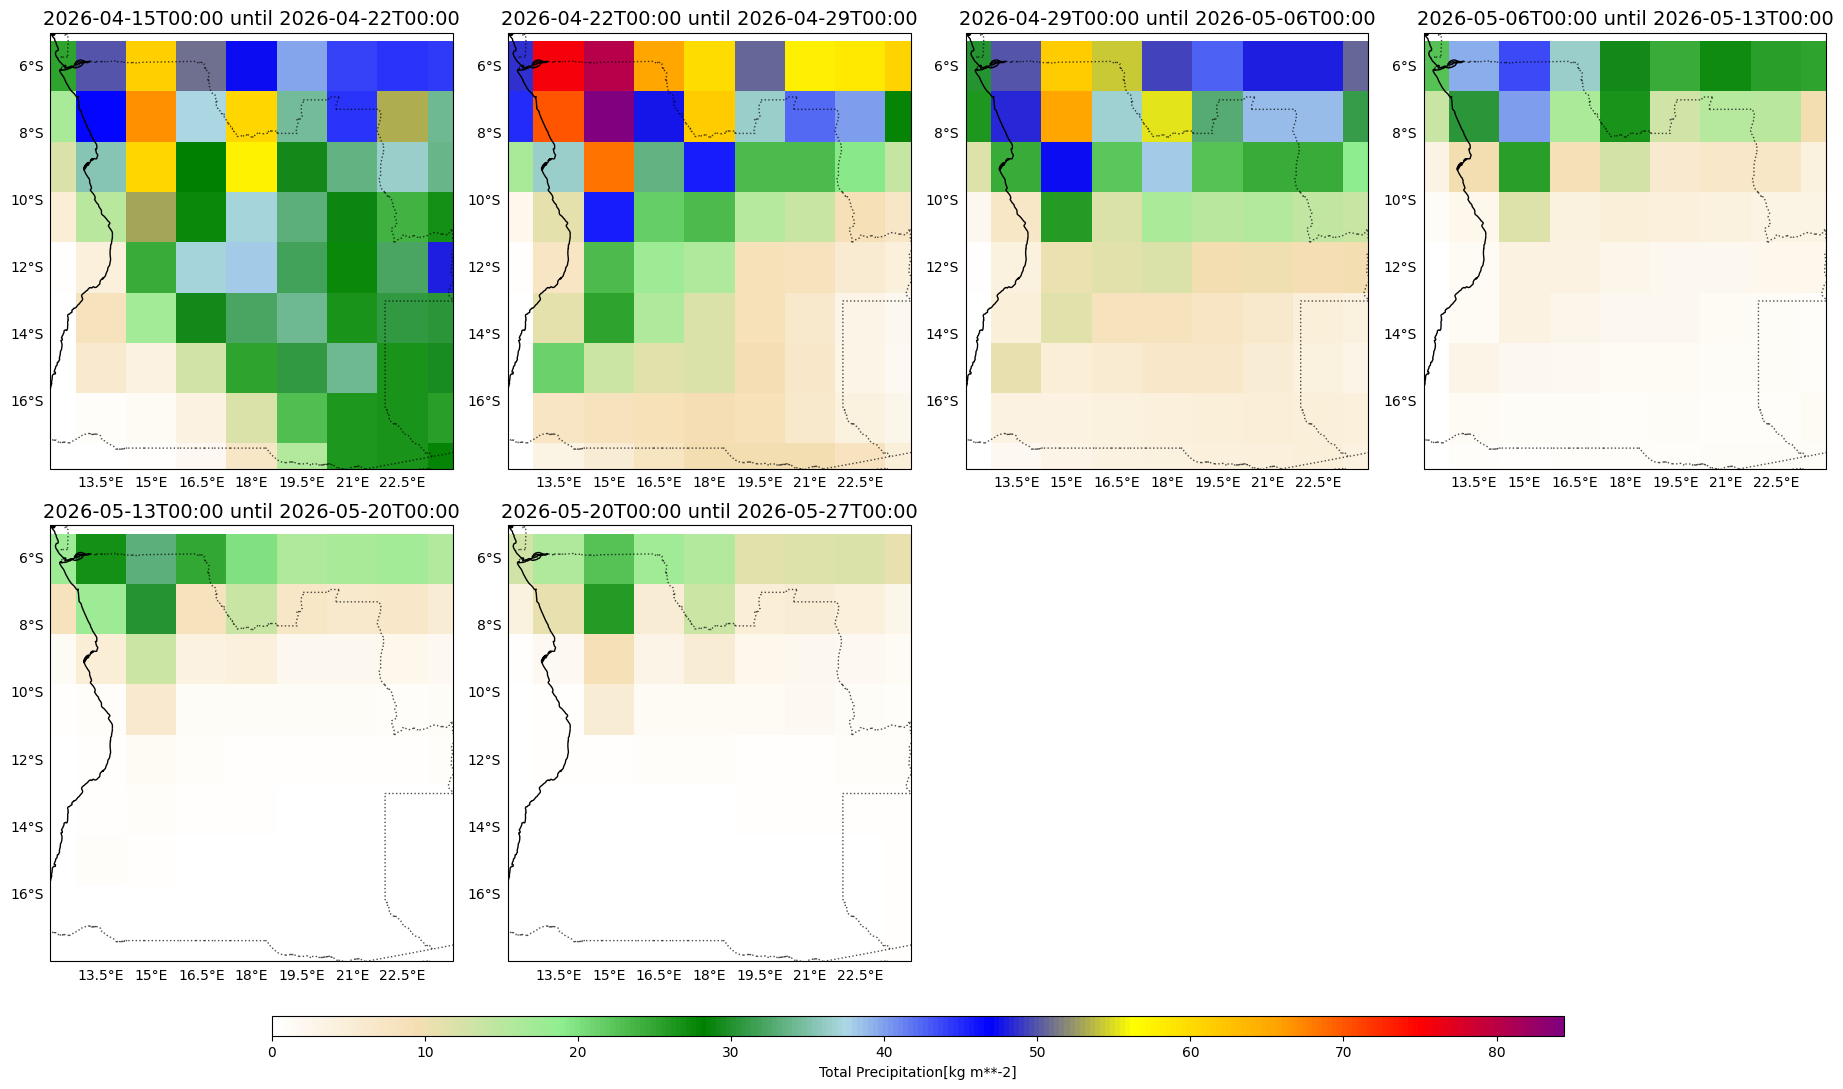

In [23]:
ds_to_plot=weekly_all_vars
fig=gef.panel_plot_variable(ds_to_plot,variable='tp',forecast_timestep=ds_to_plot.step.values,cmap=gef.cmap,fontsize=18)

## plot with contour of another variable

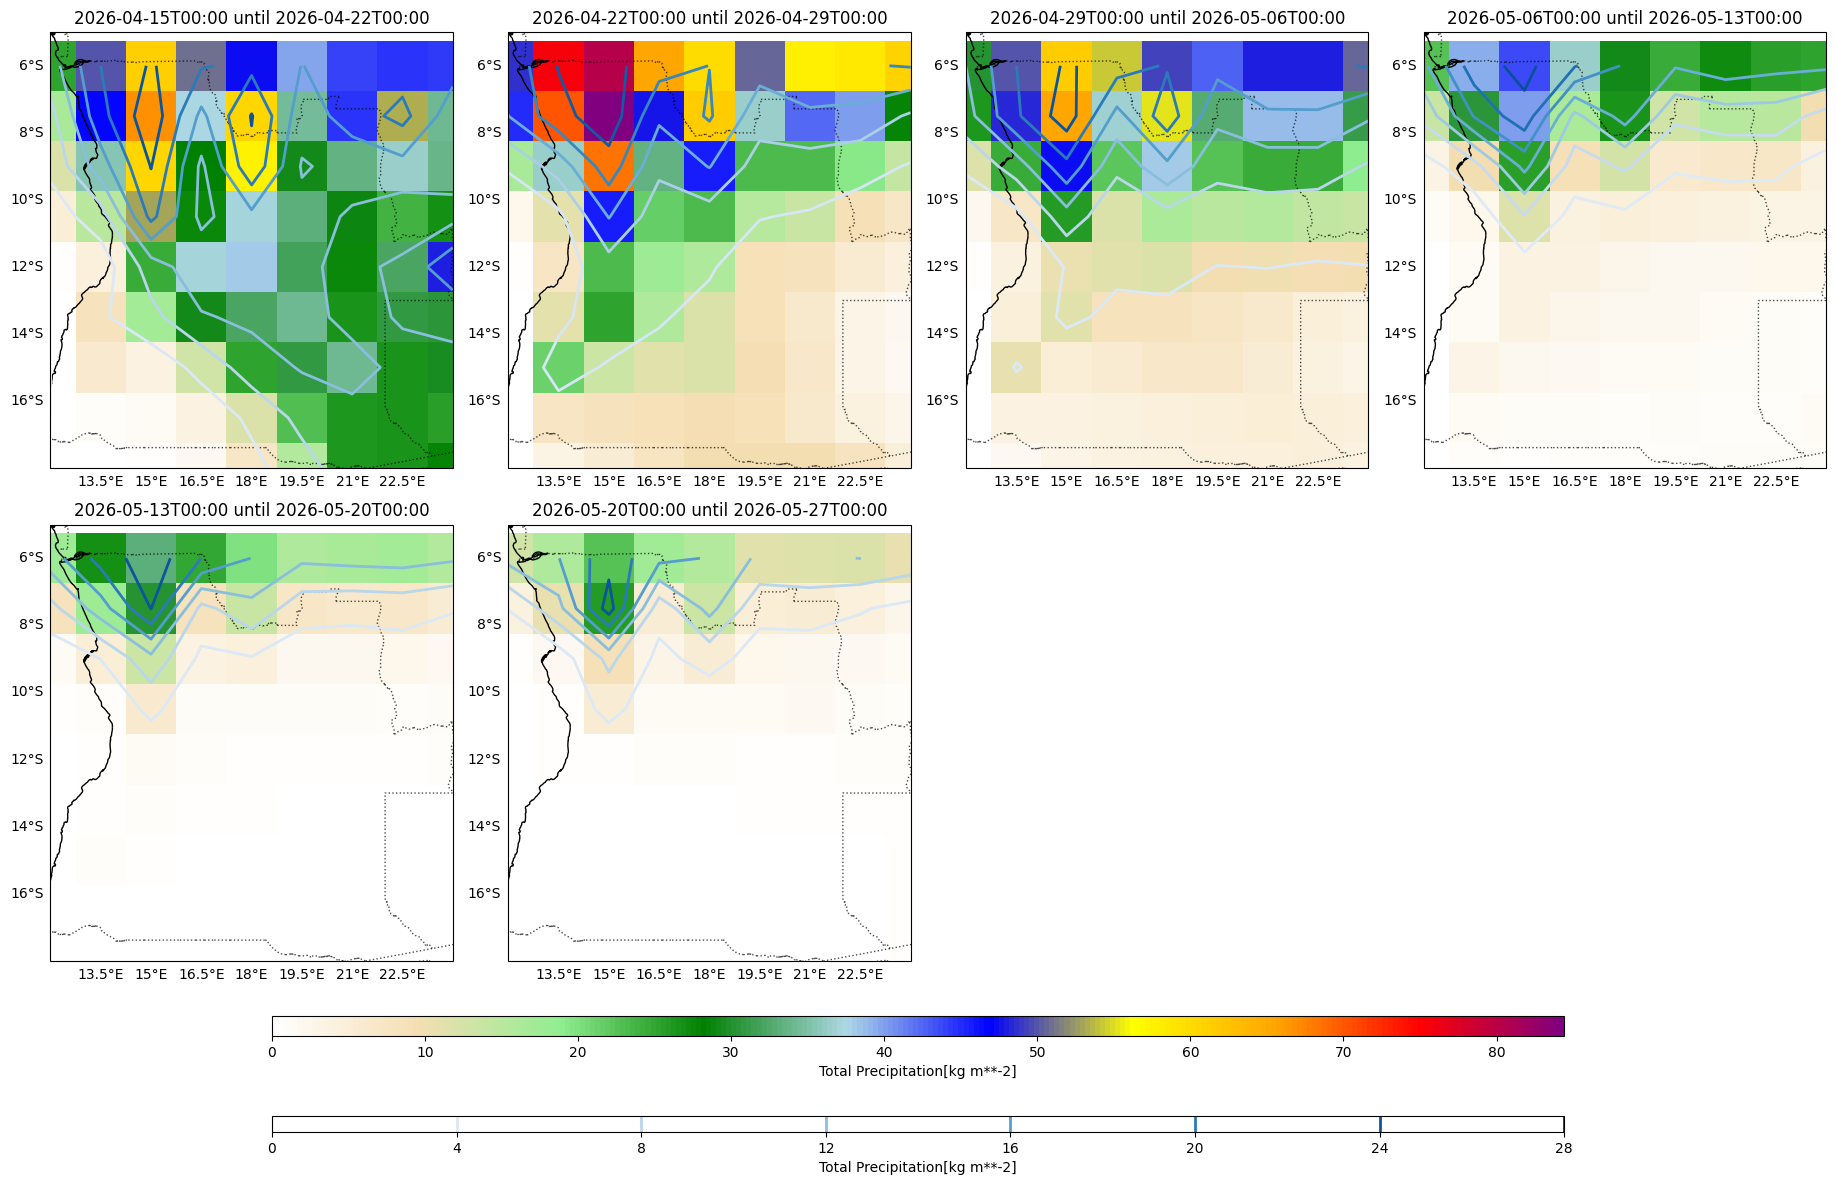

In [24]:
ds_to_plot=weekly_all_vars
fig=gef.panel_plot_variable(ds_to_plot,variable='tp',forecast_timestep=ds_to_plot.step.values,cmap=gef.cmap,add_contour=weekly_all_vars['tp'],contourcmap='Blues')

## plot the change in a variable

/content/get_ECMWF_functions.py:368: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds_diff=xr.concat(ds_list,dim='step')


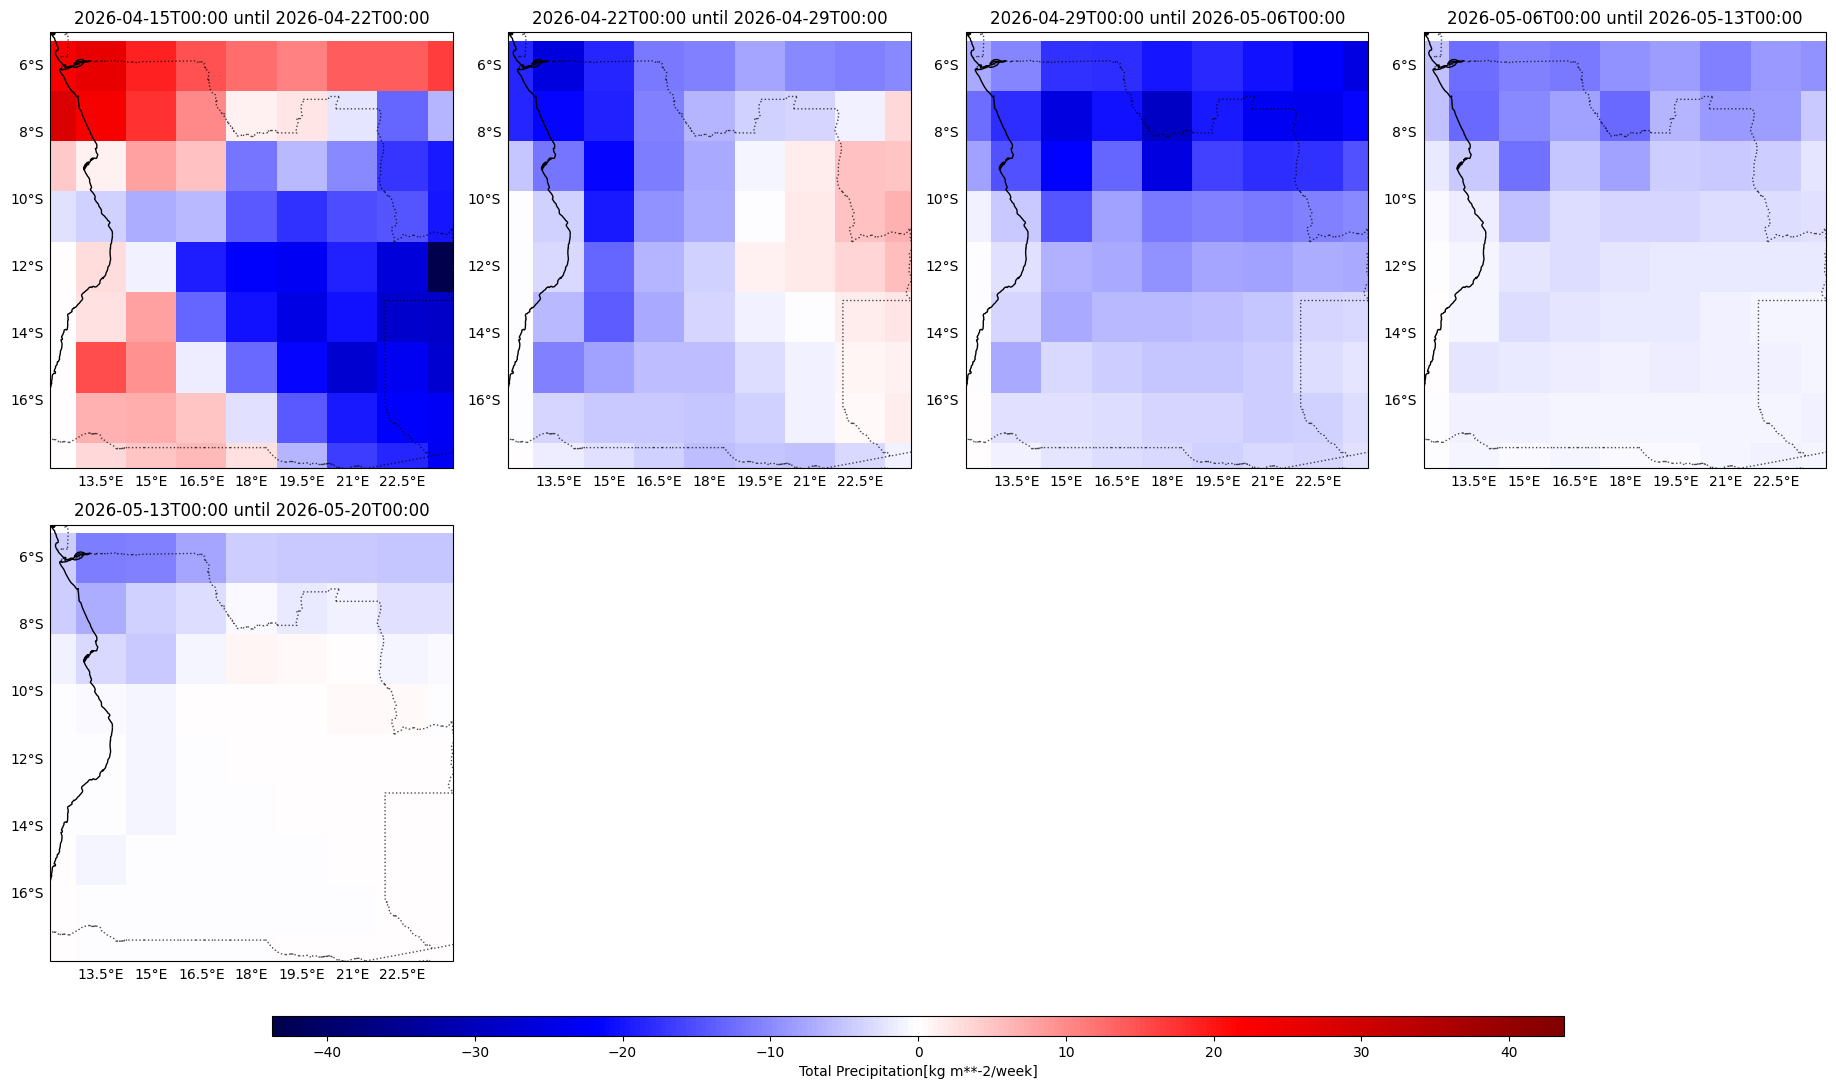

In [28]:
fontsize=16
ds_to_plot=weekly_all_vars
fig=gef.panel_plot_variable(ds_to_plot,variable='tp',forecast_timestep=ds_to_plot.step.values,cmap='seismic',change=True)

## Plot chance to exceed a certain condition

only works, if you download the ensemble members

possible conditions:

'greater', 'smaller', 'equal', 'not equal', 'greater or equal', 'smaller or equal'

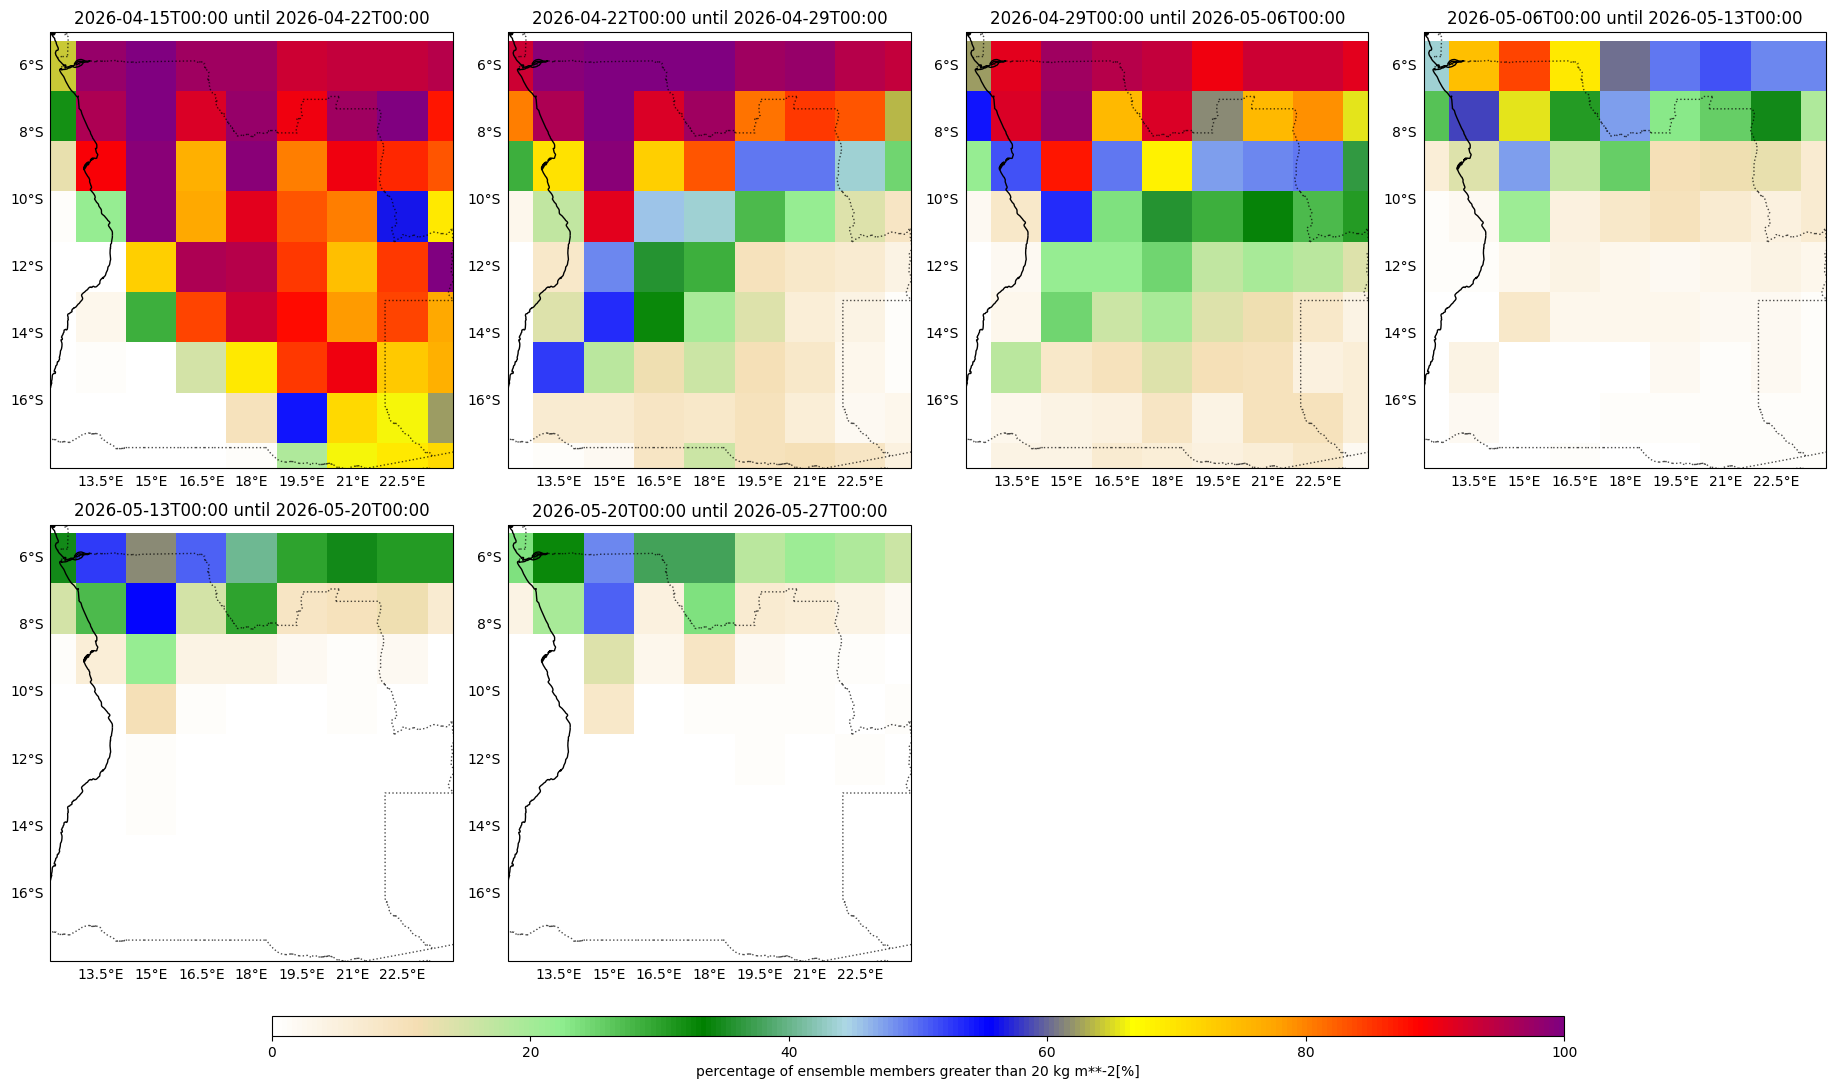

In [29]:
var='tp'
exceedance_percentage=gef.get_exceedance_percentage(weekly_all_vars,var,20,comparison='greater')
fig=gef.panel_plot_variable(exceedance_percentage,var,exceedance_percentage.step.values,cmap=gef.cmap)

## Load the model climatology

In [ ]:
m_climate=gef.open_mclimate(weekly_all_vars,colab=True)

Model climatology starting on: 2025-04-15


## take a look at the model climatology

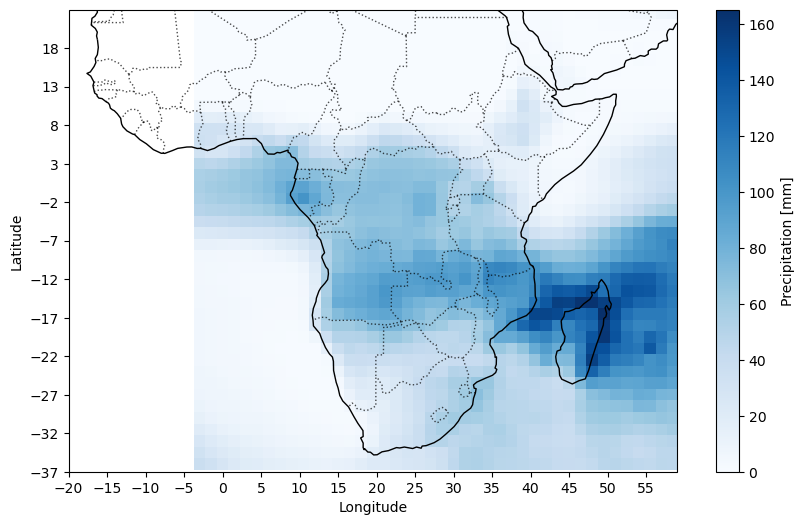

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})
data=m_climate.isel(time=0).isel(quantile=90).sel(longitude=slice(lon1,lon2),latitude=slice(lat1,lat2))
cmap='Blues'
contour=ax.pcolormesh(data.longitude, data.latitude,data.tp, cmap=cmap)
ax.set_extent([lon1, lon2, lat2, lat1], crs=ccrs.PlateCarree())
# Add natural features for context (e.g., coastlines, borders)
ax.add_feature(cfeature.COASTLINE, edgecolor='black')
ax.add_feature(cfeature.BORDERS, linestyle=':',alpha=0.7)

# Set tick marks for the longitude and latitude axes
ax.set_xticks(range(int(lon1), int(lon2), 5))  # Longitude ticks from 10 to 25
ax.set_yticks(range(int(lat2), int(lat1), 5))  # Latitude ticks from -30 to -15

# Add axis labels
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.colorbar(contour,label='Precipitation [mm]')

# EFI

C:\Users\alecj\Anaconda\envs\get_ECWMF\Lib\site-packages\numpy\_core\function_base.py:162: RuntimeWarning: invalid value encountered in multiply
  y *= step
C:\Users\alecj\Anaconda\envs\get_ECWMF\Lib\site-packages\numpy\_core\function_base.py:162: RuntimeWarning: invalid value encountered in multiply
  y *= step
C:\Users\alecj\Anaconda\envs\get_ECWMF\Lib\site-packages\numpy\_core\function_base.py:162: RuntimeWarning: invalid value encountered in multiply
  y *= step
C:\Users\alecj\Anaconda\envs\get_ECWMF\Lib\site-packages\numpy\_core\function_base.py:162: RuntimeWarning: invalid value encountered in multiply
  y *= step
C:\Users\alecj\Anaconda\envs\get_ECWMF\Lib\site-packages\numpy\_core\function_base.py:162: RuntimeWarning: invalid value encountered in multiply
  y *= step
C:\Users\alecj\Anaconda\envs\get_ECWMF\Lib\site-packages\numpy\_core\function_base.py:162: RuntimeWarning: invalid value encountered in multiply
  y *= step


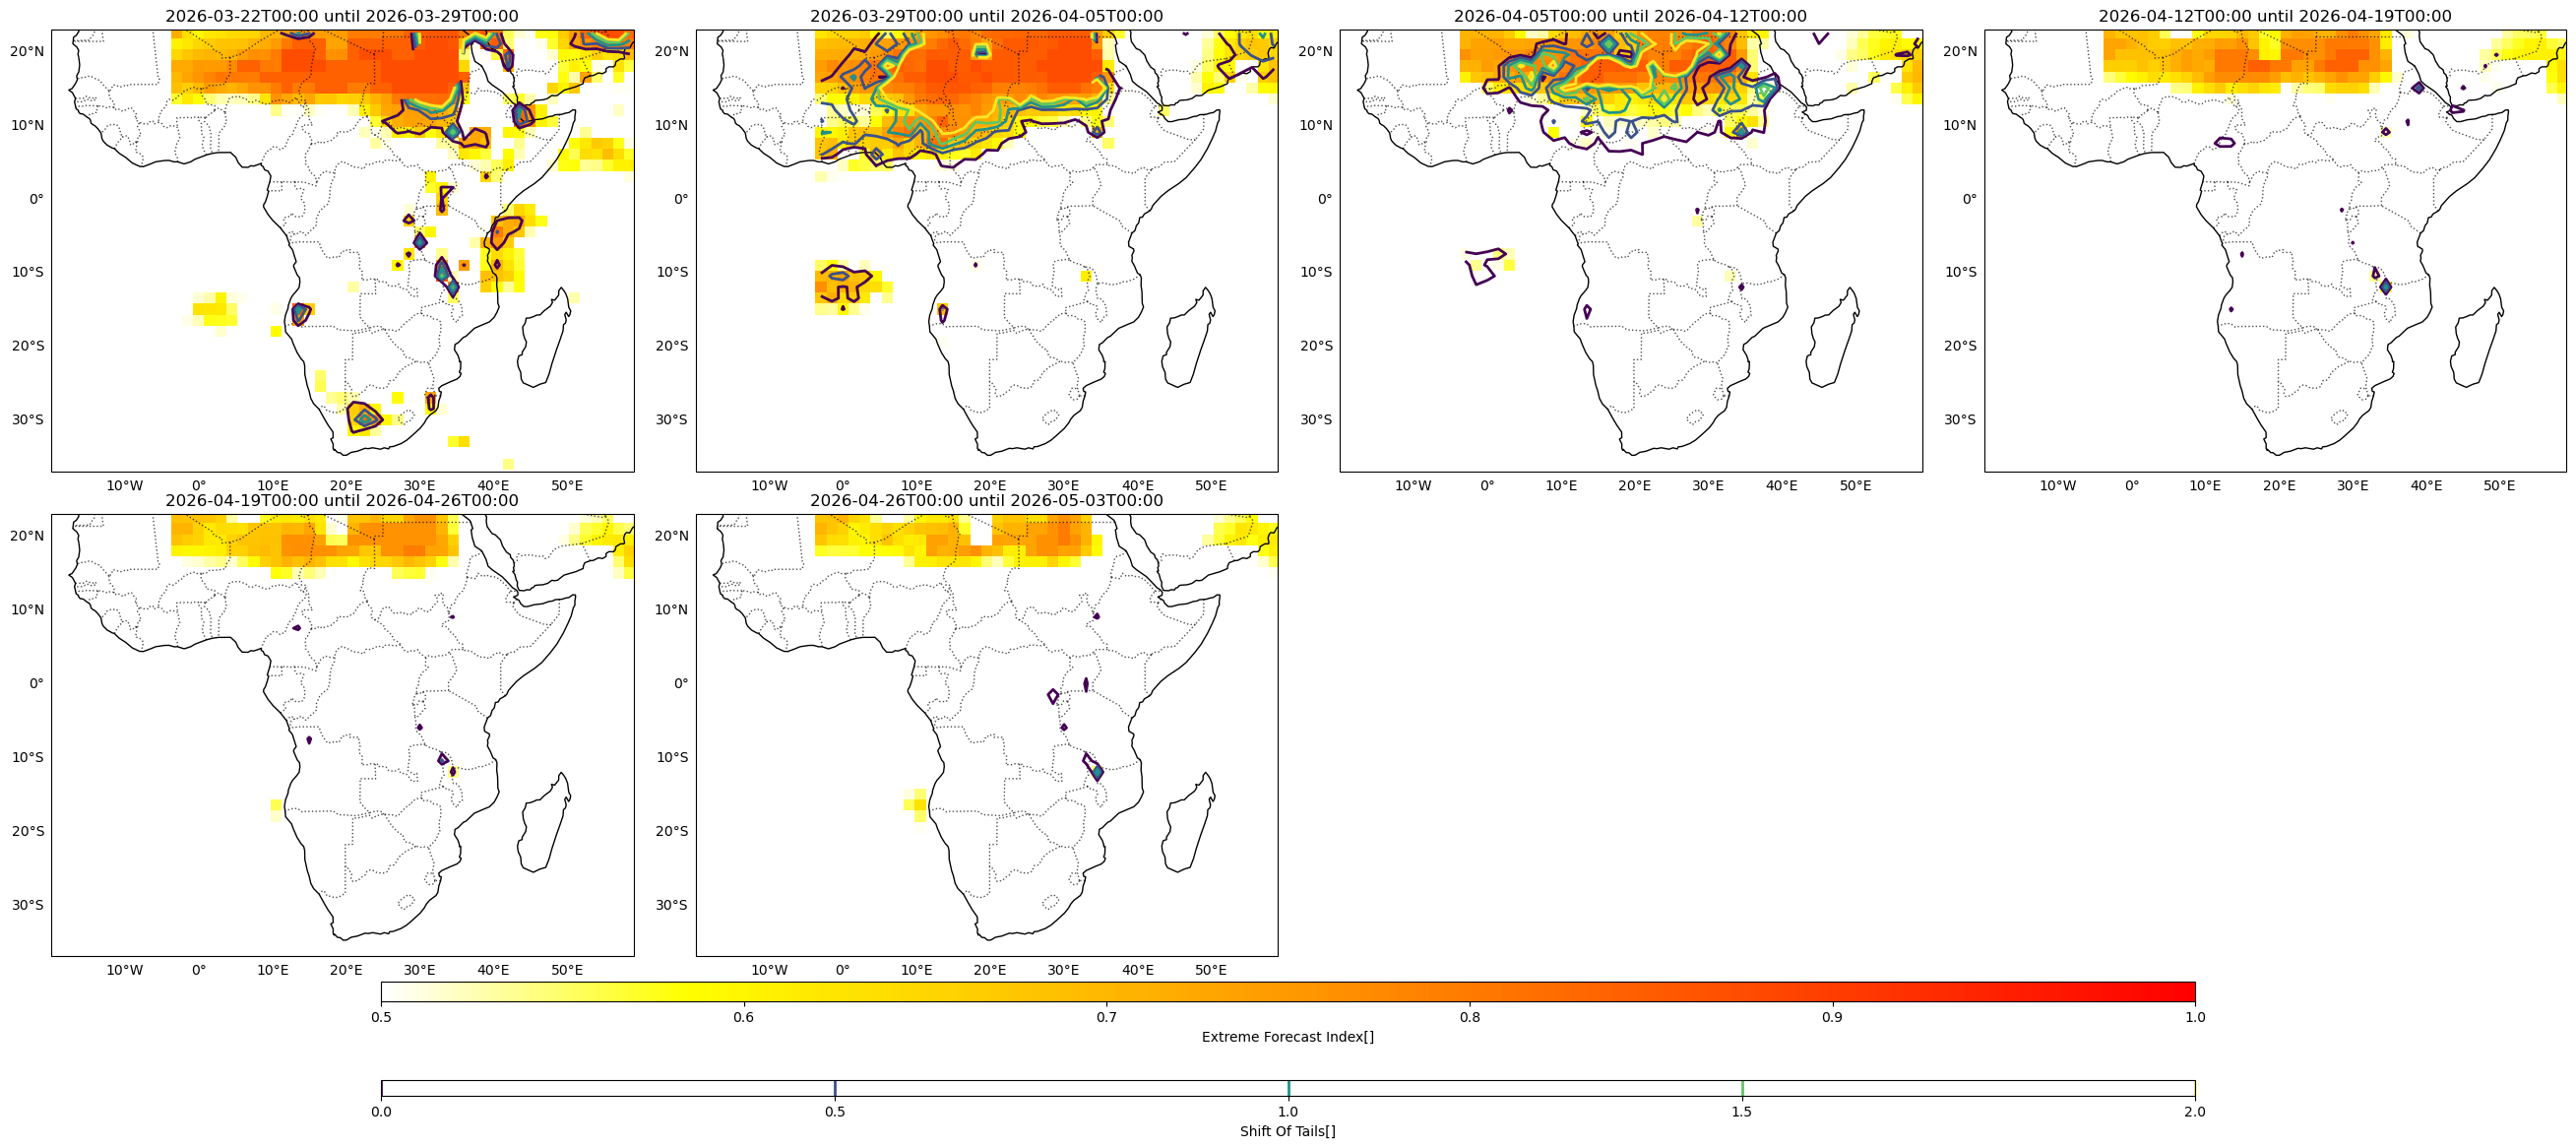

In [ ]:
ds_to_plot=efi

colors_upper = gef.cmap_efi
fig=gef.panel_plot_variable(ds_to_plot,variable='tp',forecast_timestep=ds_to_plot.step.values,vmax=1,vmin=0.5,cmap=colors_upper,add_contour=sot.tp,contourlevels=np.linspace(0,2,5))

## Plot chance to exceed quantile of the model climatology

C:\Users\alecj\Bureaublad\ECMWF-S2S4AFRICA\get_ECMWF_functions.py:1086: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  chance_to_exceed.attrs['GRIB_name']='chance to exceed climatology'


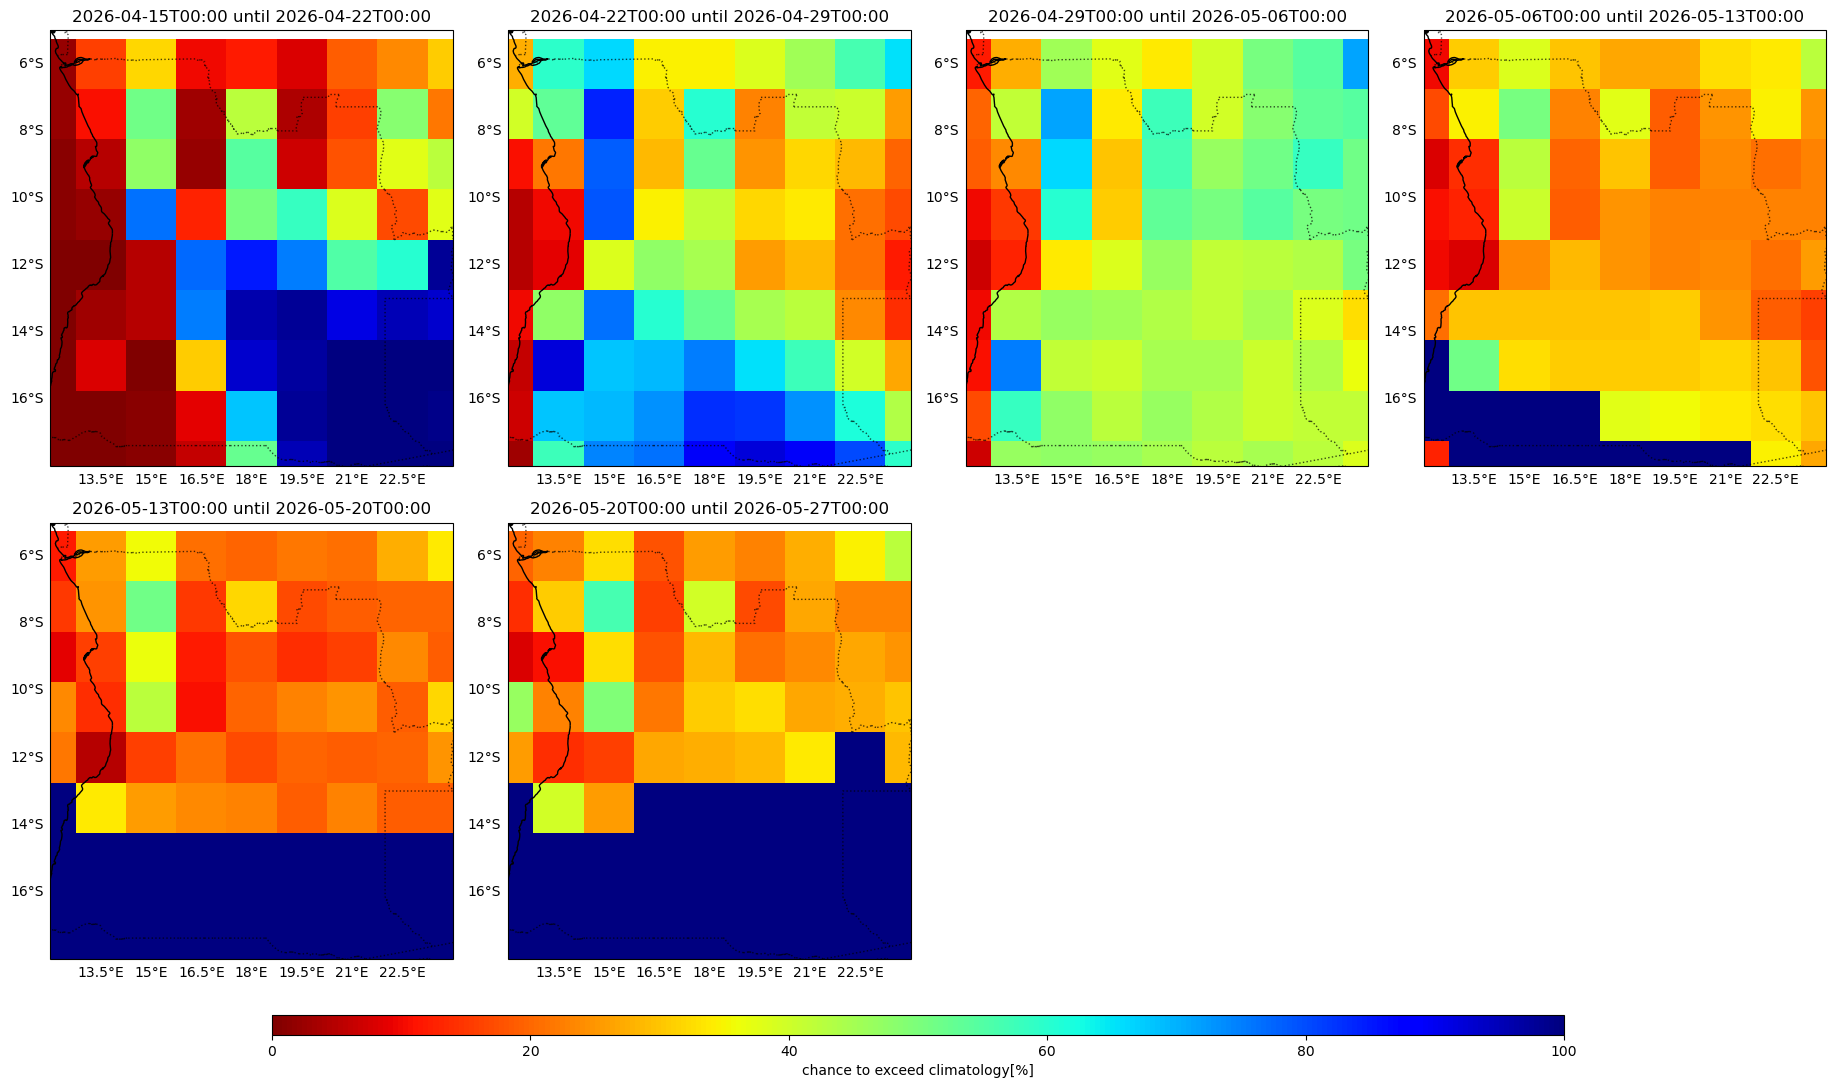

In [ ]:
chance_to_exceed=gef.chance_to_exceed_mclimate(weekly_all_vars,quantile=75,m_climate=m_climate)
fig=gef.panel_plot_variable(chance_to_exceed,'tp',chance_to_exceed.step.values,cmap='jet_r',fontsize=16)

## Plot anomaly of the ensemble mean from quantile of the model climatology

C:\Users\alecj\Bureaublad\ECMWF-S2S4AFRICA\get_ECMWF_functions.py:1086: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  anom_clim=xr.concat(hold,dim='step')


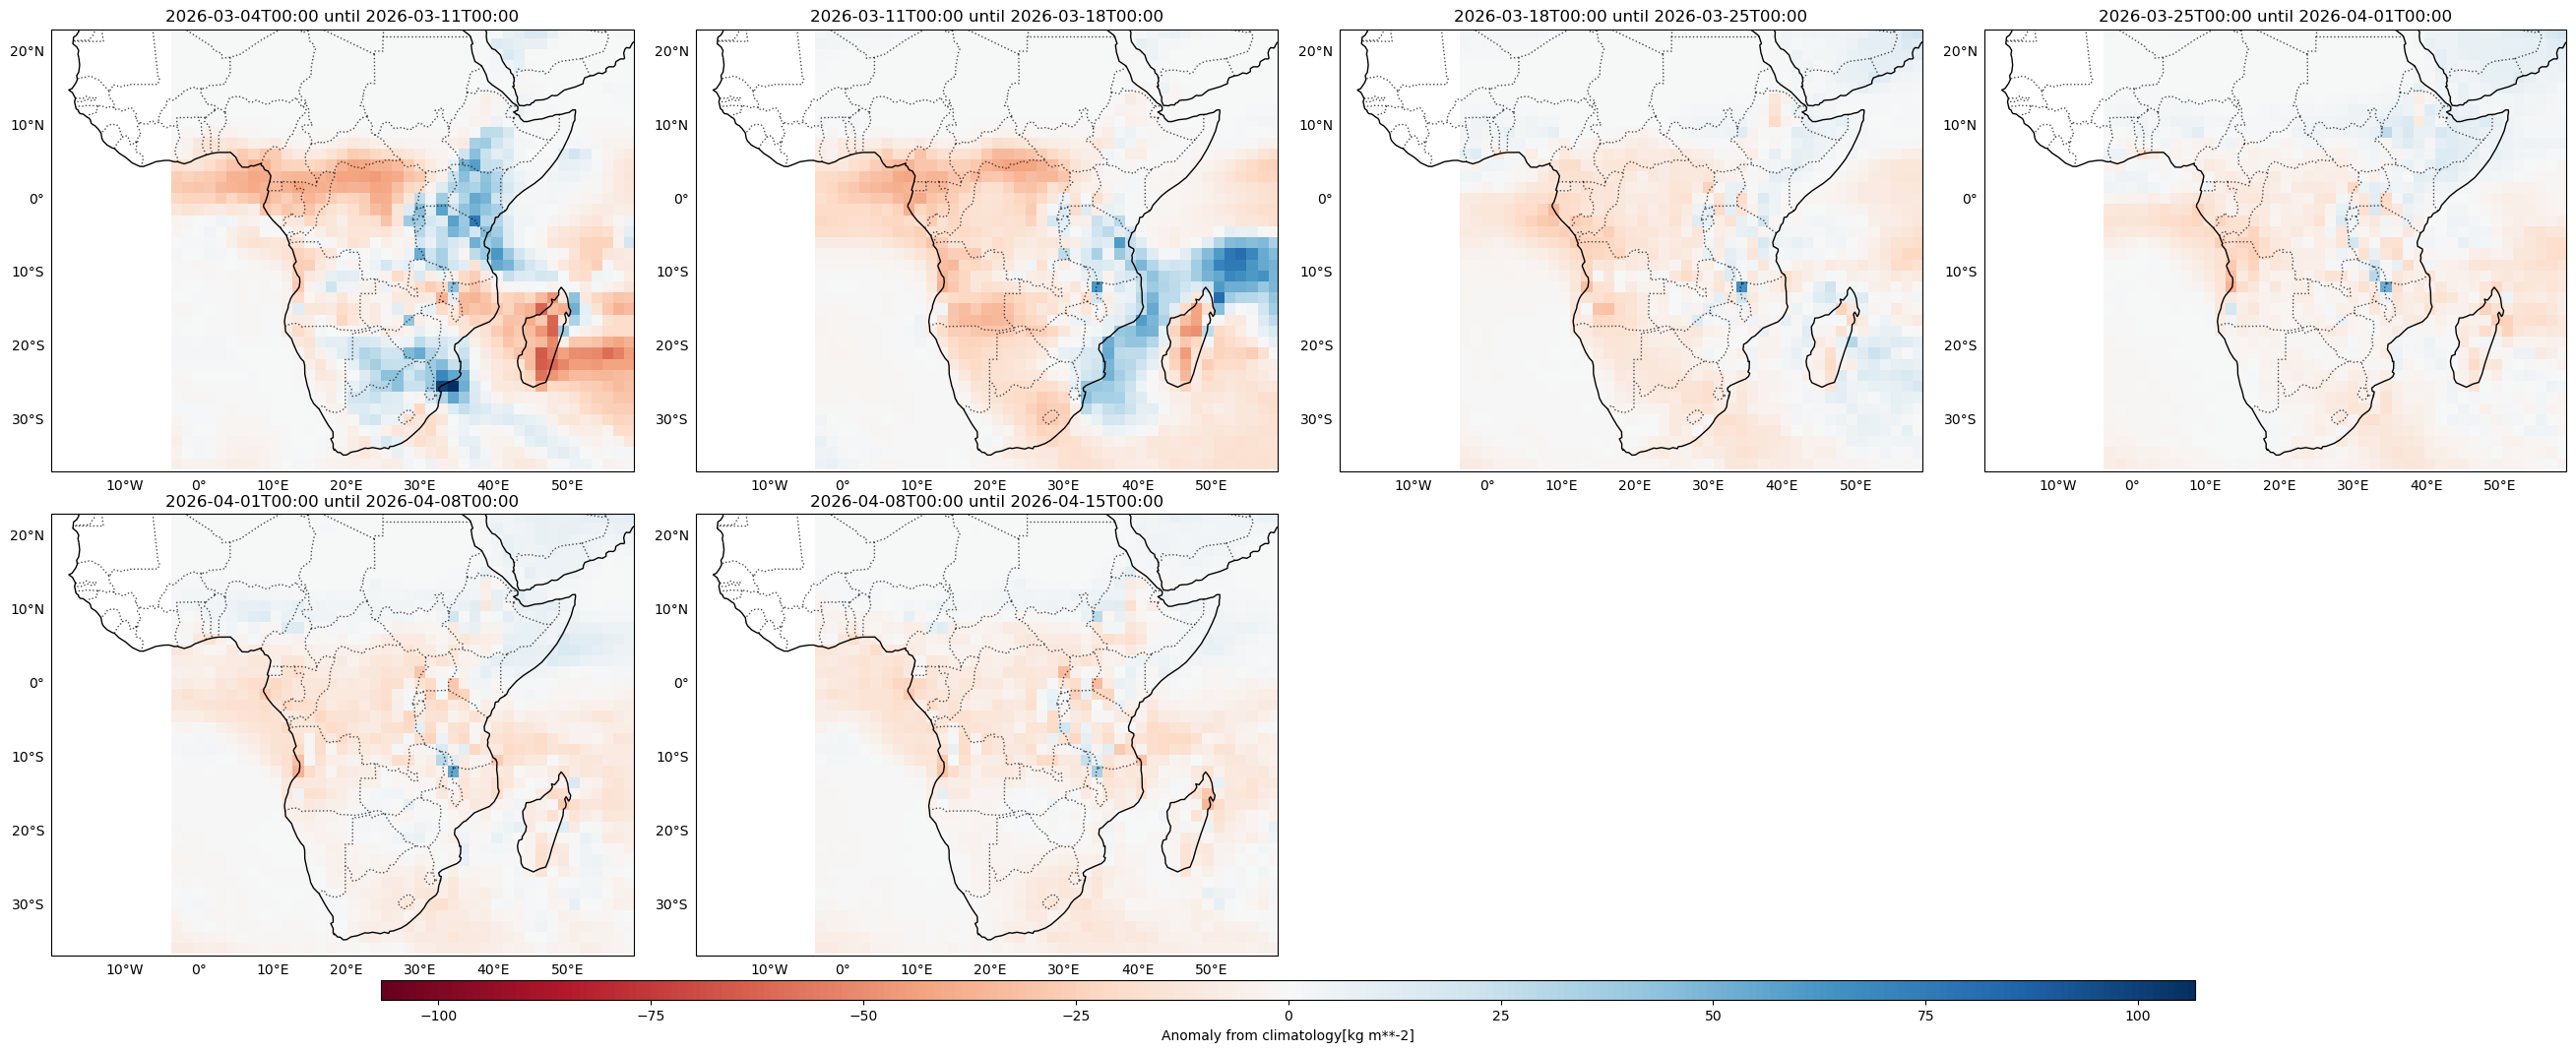

In [ ]:
anom_clim=gef.anomaly_from_mclimate(weekly_all_vars,quantile=75,m_climate=m_climate)
fig=gef.panel_plot_variable(anom_clim,'tp',anom_clim.step.values,cmap='RdBu',fontsize=16)

## Plot chance of forecast being in a tercile catagory of the model climatology

C:\Users\alecj\Bureaublad\ECMWF-S2S4AFRICA\get_ECMWF_functions.py:1123: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  tercile_clim=xr.concat(hold,dim='step')


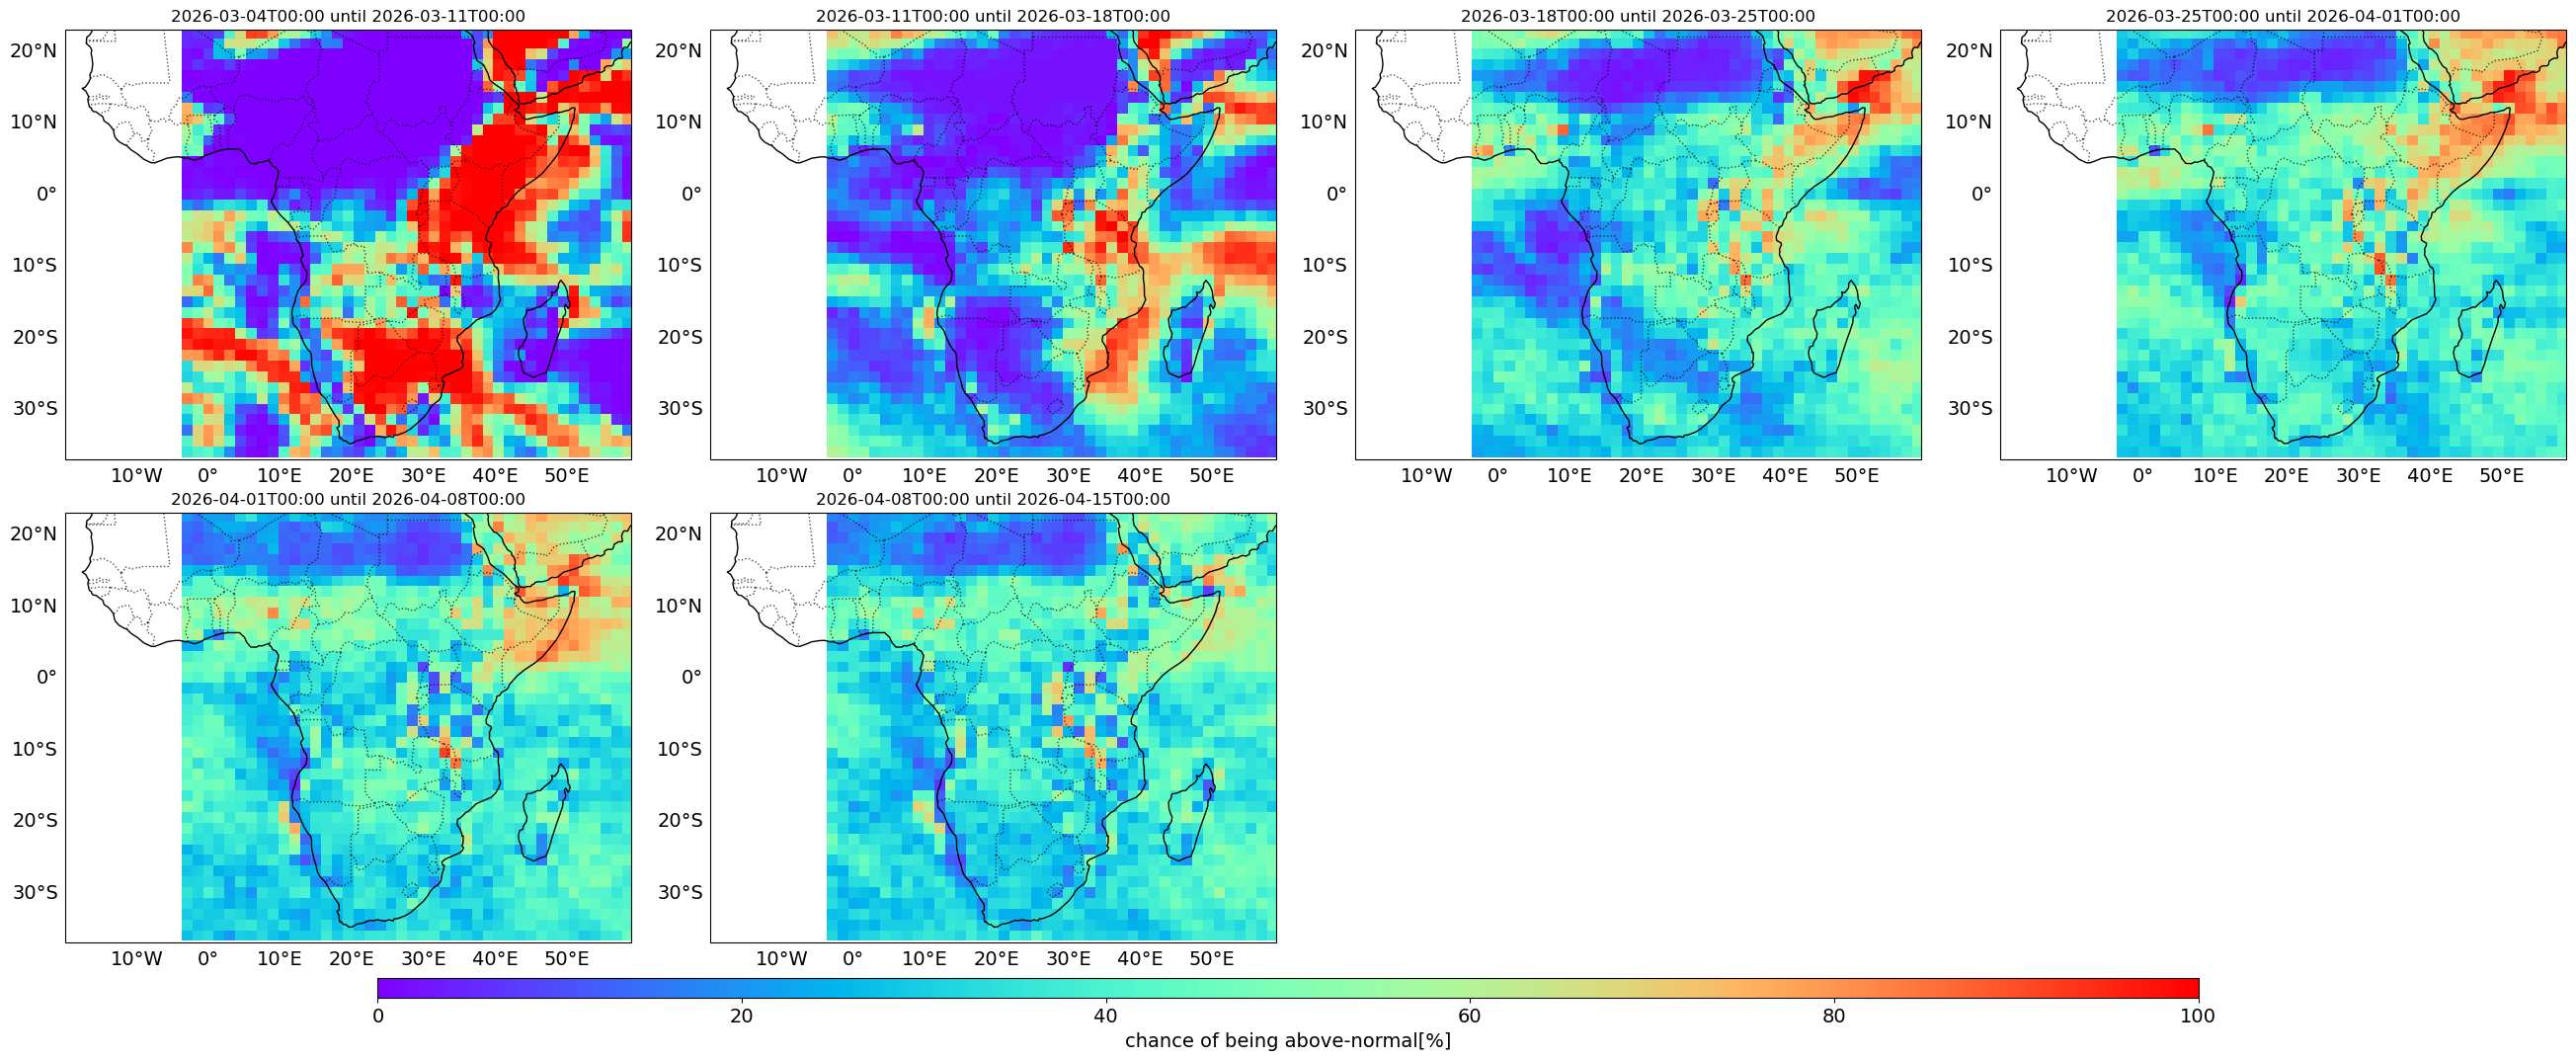

In [ ]:
fontsize=14
plt.rcParams.update({'font.size': fontsize})
tercile_clim=gef.tercile_from_mclimate(weekly_all_vars,'tp',category_choice='above-normal',m_climate=m_climate)
fig=gef.panel_plot_variable(tercile_clim,'tp',tercile_clim.step.values,cmap='rainbow')

# Meteogram
boxes show the min,10th,25th,median,75th,90th & max for the data.

shading shows from 10th to 25h, 25th to 75th & 75th to 90th of the climatology, gray line in middle of shading is the median


<Axes: title={'center': 'Meteogram: Box-and-Whisker Plot compared to climatology for lat: -1.5 lon: 36.0'}, xlabel='Forecast Time Step', ylabel='Precipitation (mm/day)'>

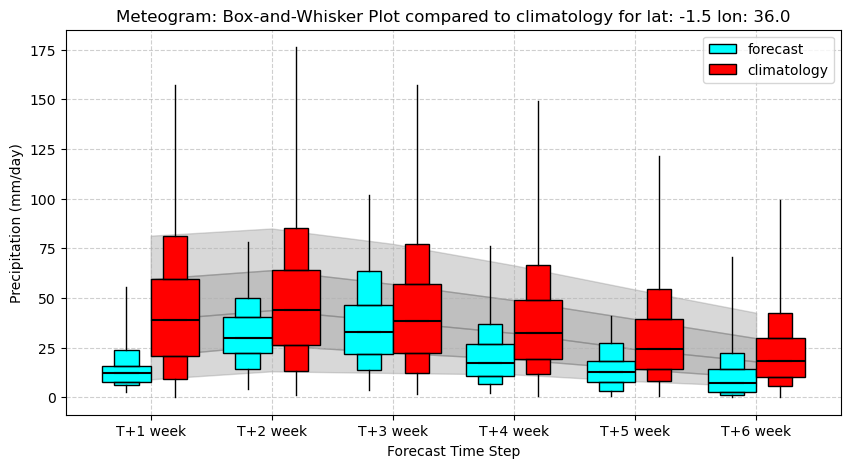

In [ ]:
gef.meteogram_double(weekly_all_vars,m_climate,lat=-1,lon=36)

### Plot a windrose for a gridbox

make a windrose for each week for a certain lat lon combination, or select a city like shown below

In [ ]:
lat=-22
lon=13
gef.make_windroses(ds_hourly,lat,lon,10,len(np.atleast_1d(weekly_all_vars.step.values)))